In [1]:
# Quantum simulation libraries
from qutip import (
    basis, 
    mesolve, 
    qeye, 
    sigmax, 
    sigmay, 
    sigmaz, 
    tensor,
    )
import qutip

# Machine learning libraries
import torch
from torch import nn
from torch.utils.data import DataLoader, Dataset

# Plotting libraries
import matplotlib.pyplot as plt
from rich.progress import track
import seaborn as sns

# Linalg libraries
import numpy as np
from scipy.stats import pearsonr

# Helper libraries
from dataclasses import dataclass


In [2]:
# set the device
device = (
    "cuda"
    if torch.cuda.is_available()
    else "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)
print(f"Using {device} device")

Using mps device


# Load target data

In [3]:
times = np.linspace(0, 5, 2000)
b_field = np.sin(2 * np.pi * times)

# Run Simulation

In [4]:
@dataclass
class SimulationParameters:
    """
    Helper class for the simulation parameters.
    """
    length: int
    coupling: list

@dataclass
class SimulationState:
    """ 
    Helper class for the simulation state.
    """
    number_of_spins: int
    quantum_state: list
    spin_list: list
    coupling_list: list

In [5]:
def get_simulation_state(parameters: SimulationParameters):
    """
    Returns the initial state of the simulation.
    """
    # Get the initial wavefunction
    number_of_spins = parameters.length ** 2
    initial_state = []
    for i in range(number_of_spins):
        initial_state.append(
            basis(2, 0)
        )

    # Setup operators for individual qubits
    sx_list, sy_list, sz_list = [], [], []
    for i in range(number_of_spins):
        op_list = [qeye(2)] * number_of_spins
        op_list[i] = sigmax()
        sx_list.append(tensor(op_list))
        op_list[i] = sigmay()
        sy_list.append(tensor(op_list))
        op_list[i] = sigmaz()
        sz_list.append(tensor(op_list))

    # Setup the operators for the coupling
    Jx = parameters.coupling * np.ones(number_of_spins)
    Jy = parameters.coupling * np.ones(number_of_spins)
    Jz = parameters.coupling * np.ones(number_of_spins)    

    return SimulationState(
        number_of_spins=number_of_spins,
        quantum_state=tensor(initial_state),
        spin_list=[sx_list, sy_list, sz_list],
        coupling_list=[Jx, Jy, Jz],
    )

In [6]:
def compute_hamiltonian(t, args):
    """
    Compute the Hamiltonian at time t.
    
    Parameters
    ----------
    t : float
        Current time.
    args : dict
        System parameters in the H computation.
    """
    sx_list = args["sx_list"]
    sy_list = args["sy_list"]
    sz_list = args["sz_list"]
    Jx = args["Jx"]
    Jy = args["Jy"]
    Jz = args["Jz"]
    driving_field = args["driving"]

    N = args["N"]
    length = int(np.sqrt(N))

    # Magnetic field terms to top row
    H = 0
    for i in range(N):        
        H -= driving_field[t] * sz_list[i]
    
    lattice_sites = []
    for x in range(length):
        for y in range(length):
            lattice_sites.append([x, y])

    lattice_sites = np.array(lattice_sites)
    neighbours = np.array([[1, 0], [-1, 0], [0, 1], [0, -1]]) # right, left, top, bottom
    box_l = np.array([length, length])

    # Interaction terms
    spin_coupling_term = 0
    for n, site in enumerate(lattice_sites):

        neighbours = site[None, :] + neighbours
        neighbours_folded = neighbours - np.floor(neighbours / box_l[None, :]) * box_l[None, :]
        neighbour_indices = neighbours_folded[:, 0] + length * neighbours_folded[:, 1]

        for neighbour in neighbour_indices:
            spin_coupling_term += -0.5 * Jx[n] * sx_list[n] * sx_list[int(neighbour)]
            spin_coupling_term += -0.5 * Jy[n] * sy_list[n] * sy_list[int(neighbour)]
            spin_coupling_term += -0.5 * Jz[n] * sz_list[n] * sz_list[int(neighbour)]

    return H + spin_coupling_term  # account for double counting

In [7]:
for strength in np.linspace(1, 10, 10, dtype=int):
    simulation_parameters = SimulationParameters(
        length=3,
        coupling=strength * np.pi,
    )
    simulation_state = get_simulation_state(simulation_parameters)

    args = {
        "sx_list": simulation_state.spin_list[0],
        "sy_list": simulation_state.spin_list[1],
        "sz_list": simulation_state.spin_list[2],
        "Jx": simulation_state.coupling_list[0],
        "Jy": simulation_state.coupling_list[1],
        "Jz": simulation_state.coupling_list[2],
        "N": simulation_state.number_of_spins,
        "driving": b_field
    }

    signal_length = b_field.shape[0]

    # Equilibration run
    hamiltonian = compute_hamiltonian(0, args)
    times = np.linspace(0, 0.1, 10)
    new_state = mesolve(hamiltonian, simulation_state.quantum_state, times, [], [], args).states[-1]
    states = []
    for t in track(range(signal_length), description="Running Simulation"):
        hamiltonian = compute_hamiltonian(t, args)
        new_state = mesolve(hamiltonian, new_state, times, [], [], args).states[-1]
        states.append(new_state)

    qutip.qsave(states, f"{strength}")

Output()

Output()

Output()

Output()

Output()

Output()

Output()

Output()

Output()

Output()

In [8]:
# Observables for state description.
state_dimension = 10

measurements = []

for _ in range(state_dimension):
    seed = np.random.randint(641)
    measurements.append(
        qutip.rand_herm(
            512,
            1.2, 
            dims=[[2, 2, 2, 2, 2, 2, 2, 2, 2], [2, 2, 2, 2, 2, 2, 2, 2, 2]]
        )
    )

In [9]:
for strength in np.linspace(1, 10, 10, dtype=int):

    # Compute observables
    observations = np.zeros((signal_length, state_dimension))
    states = qutip.qload(f"{strength}")

    for t, state in enumerate(states):
        for o, operator in enumerate(measurements):
            observations[t][o] = qutip.expect(state * state.dag(), operator)

    np.save(f"{strength}_observations.npy", observations)

# Fit Model

In [10]:
class NeuralNetwork(nn.Module):
    
    def __init__(self, state_dimension: int, output_dimension: int):
        """
        Build the network.
        
        Parameters
        ----------
        state_dimension : int
                Dimension of the state representation.
                This is the input to the layer.
        output_dimension : int
                Dimension of the output being predicted.
        """
        super().__init__()


        self.linear_stack = nn.Sequential(
            nn.Linear(state_dimension, 256),
            nn.ReLU(),
            nn.Linear(256, 256),
            nn.ReLU(),
            nn.Linear(256, output_dimension),
        )
    
    def forward(self, x):
        """
        Forward pass through the network.
        
        As we are doing reservoir computing, this is 
        simply a linear layer.
        """
        return self.linear_stack(x)

In [11]:
class ReservoirDataset(Dataset):
    """
    Custom dataset for the training.
    """
    def __init__(
        self, 
        state_data: np.ndarray, 
        prediction_length: int,
        function_data: np.ndarray,
    ):
        """
        Constructor for the dataset.

        Parameters
        ----------
        state_data : np.ndarray
                State description data.
        function_data : np.ndarray
                Function data being fit.
                This will be the target data.
        prediction_length : int
                How far into the future you will predict.
        """
        self.state_data = torch.Tensor(state_data[:-prediction_length, :]).to(device)

        self.function_data = torch.Tensor(
            function_data[prediction_length:].reshape(-1, 1)
        ).to(device)
        
        self.norm_factor = 1 # max(abs(function_data.flatten()))

    def split_data(self, train_size: float):
        """
        Split the data into training and validation sets.
        
        Parameters
        ----------
        train_size : float
                Size of the training set.
        """
        train_size = int(train_size * len(self))
        val_size = len(self) - train_size
        return torch.utils.data.random_split(self, [train_size, val_size])
    
    def __len__(self):
        """
        Length of the dataset.
        """
        return int(
            len(self.function_data)
        )
    
    def __getitem__(self, idx: int):
        """
        Collect an item from the dataset.
        
        Parameters
        ----------
        idx : int
                Index of the state to take.
        """
        state = self.state_data[idx]
        target = self.function_data[idx] / self.norm_factor
        
        return state, target

In [12]:
def train(dataloader, model, loss_fn, optimizer):
    model.train()
    for batch, (X, y) in enumerate(dataloader):
        X, y = X.to(device), y.to(device)
        # Compute prediction error
        pred = model(X)
        loss = loss_fn(pred, y)

        # Backpropagation
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        if batch % 100 == 0:
            loss, current = loss.item(), (batch + 1) * len(X)
            
    return loss

In [13]:
def test(dataloader, model, loss_fn):
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    model.eval()
    test_loss, correct = 0, 0
    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            pred = model(X)
            test_loss += loss_fn(pred, y).item()
    test_loss /= num_batches
    correct /= size
    print(f"Test Error: Avg loss: {test_loss:>8f} \n")
    
    return test_loss

In [14]:
def train_model(dataset, model = None):
    """
    Train a model on the current data.
    """    
    if model is None:
        model = NeuralNetwork(
            state_dimension=10,
            output_dimension=1
        ).to(device)

        model = model.type(torch.float32)

    # Use MSE loss
    loss_fn = nn.MSELoss()

    # Use ADAM optimizer
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
    
    # Create the loader
    loader = DataLoader(dataset, batch_size=50, shuffle=False)
    
    # Train the network
    epochs = 6000
    train_losses = []

    for t in track(range(epochs)):
        loss = train(loader, model, loss_fn, optimizer)
        train_losses.append(loss)

    train_losses = [item.cpu().detach().numpy() for item in train_losses]
    
    return train_losses, model

## Train the model

In [15]:
def train_and_evaluate(strength, b_field):
    """
    Load observabe data, train and evaluate on test data.
    """
    observables = np.load(f"{strength}_observations.npy", allow_pickle=True)
    train_ds = ReservoirDataset(
        state_data=observables[:1500],
        function_data=b_field[:1500],
        prediction_length=1
    )

    test_ds = ReservoirDataset(
        state_data=observables[1500:],
        function_data=b_field[1500:],
        prediction_length=1
    )

    train_losses, model = train_model(train_ds, model=None)

    predictions = []
    targets = []
    for item in test_ds:
        state, target = item
        predictions.append(model(state).cpu().detach().numpy())
        targets.append(target.cpu().detach().numpy())

    return np.array(predictions), np.array(targets), train_losses

In [16]:
performance = {}

for strength in np.linspace(1, 10, 10, dtype=int):
    predictions, targets, train_losses = train_and_evaluate(strength, b_field)
    performance[strength] = {
        "predictions": predictions,
        "targets": targets,
        "train_losses": train_losses
    }

Output()

Output()

Output()

Output()

Output()

Output()

Output()

Output()

Output()

Output()

In [17]:
performance = np.save("train_results.npy", performance)
performance = np.load("train_results.npy", allow_pickle=True).item()

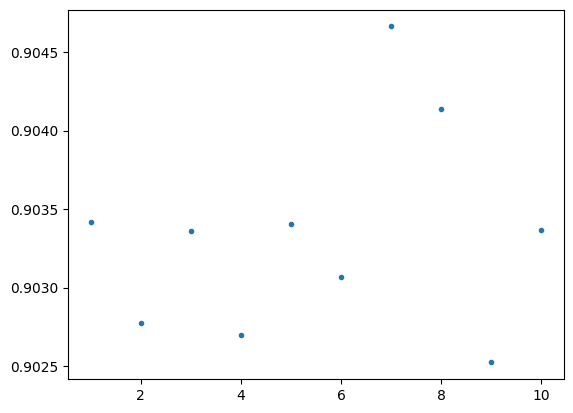

In [18]:
plt.plot(list(performance.keys()), [item["train_losses"][-1] for item in performance.values()], '.')
plt.show()

In [19]:
r2_scores = []

for key, value in performance.items():
    print(value["predictions"])
    r2_scores.append(pearsonr(value["predictions"].flatten(), value["targets"].flatten())[0])

[[0.04125705]
 [0.04125705]
 [0.04125705]
 [0.04125705]
 [0.04125705]
 [0.04125705]
 [0.04125705]
 [0.04125705]
 [0.04125705]
 [0.04125705]
 [0.04125705]
 [0.04125705]
 [0.04125705]
 [0.04125705]
 [0.04125705]
 [0.04125705]
 [0.04125705]
 [0.04125705]
 [0.04125705]
 [0.04125705]
 [0.04125705]
 [0.04125705]
 [0.04125705]
 [0.04125705]
 [0.04125705]
 [0.04125705]
 [0.04125705]
 [0.04125705]
 [0.04125705]
 [0.04125705]
 [0.04125705]
 [0.04125705]
 [0.04125705]
 [0.04125705]
 [0.04125705]
 [0.04125705]
 [0.04125705]
 [0.04125705]
 [0.04125705]
 [0.04125705]
 [0.04125705]
 [0.04125705]
 [0.04125705]
 [0.04125705]
 [0.04125705]
 [0.04125705]
 [0.04125705]
 [0.04125705]
 [0.04125705]
 [0.04125705]
 [0.04125705]
 [0.04125705]
 [0.04125705]
 [0.04125705]
 [0.04125705]
 [0.04125705]
 [0.04125705]
 [0.04125705]
 [0.04125705]
 [0.04125705]
 [0.04125705]
 [0.04125705]
 [0.04125705]
 [0.04125705]
 [0.04125705]
 [0.04125705]
 [0.04125705]
 [0.04125705]
 [0.04125705]
 [0.04125705]
 [0.04125705]
 [0.04

/Users/samueltovey/miniconda3/envs/zincware/lib/python3.10/site-packages/scipy/stats/_stats_py.py:4781: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(msg))


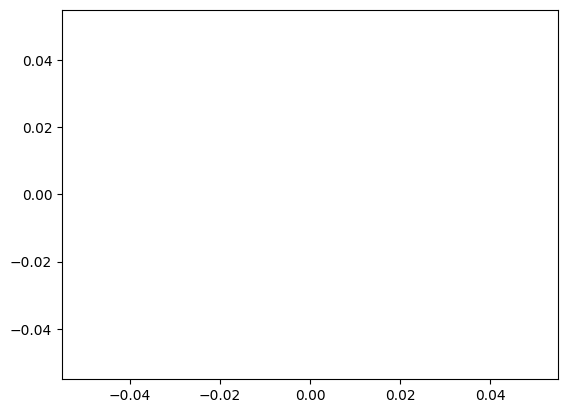

In [20]:
plt.plot(
    list(performance.keys()), 
    r2_scores, 
    '.'

)

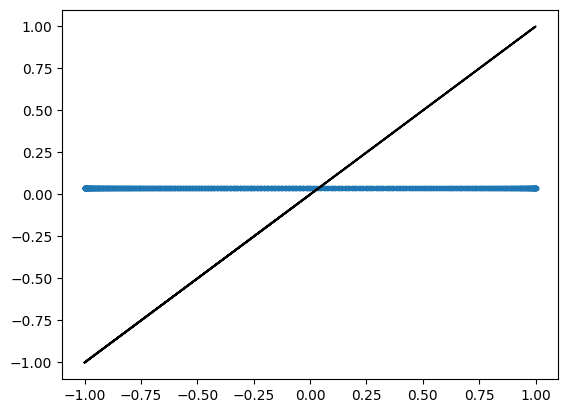

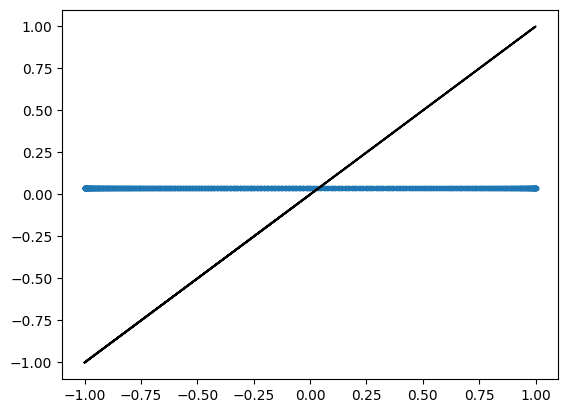

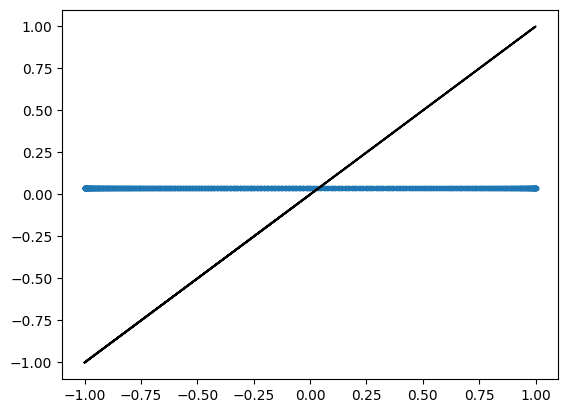

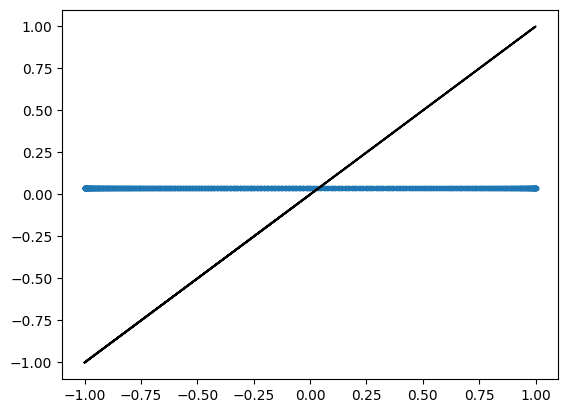

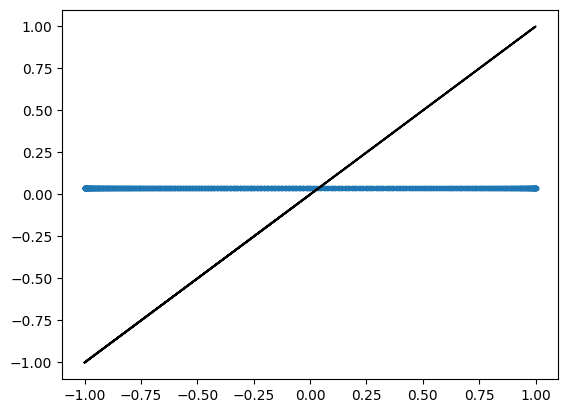

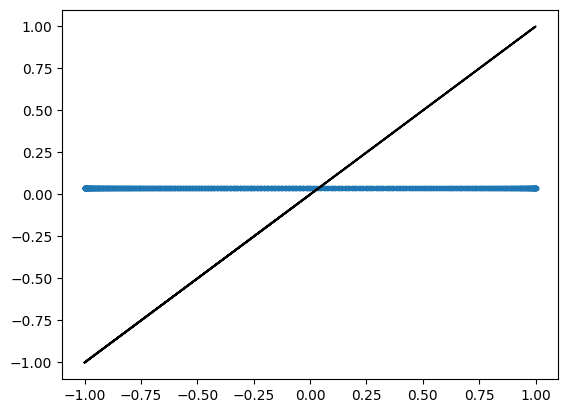

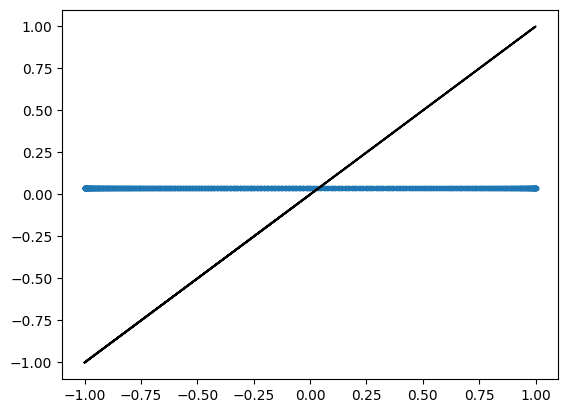

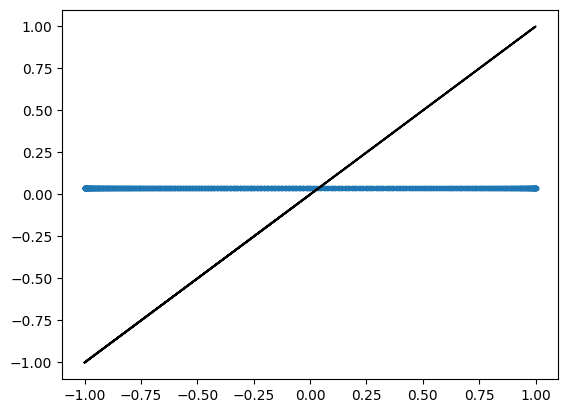

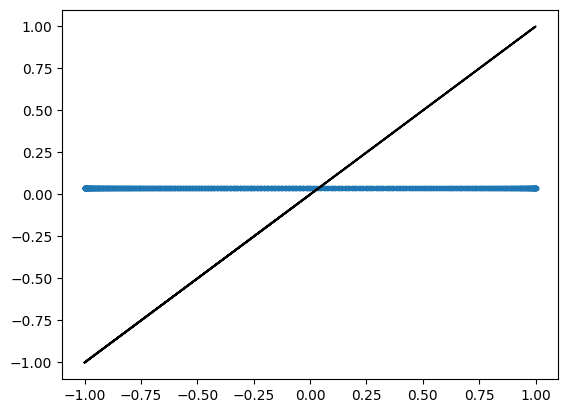

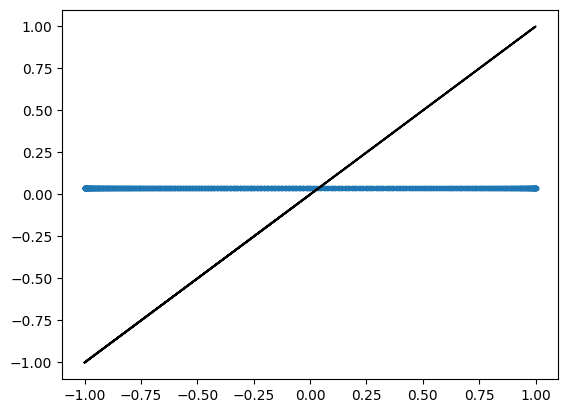

In [21]:
for i in np.linspace(1, 10, 10, dtype=int):
    plt.plot(performance[i]["targets"], performance[1]["predictions"], '.')
    plt.plot(performance[i]["targets"], performance[1]["targets"], 'k-')
    plt.show()